In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

In [2]:
rootDir="/content/drive/MyDrive/SYNC_Projects/"
rootDir=rootDir+"pBGT/ms/"

dataPath=rootDir+"data/analysis/pBGT_CN_vs_Fluorescence/data_text/"
outdataPath=rootDir+"data/analysis/pBGT_CN_vs_Fluorescence/"

files=os.listdir(dataPath)

files.sort()
files

['g54u.txt', 'g55u-noamp.txt', 'g55u.txt', 'mg-gt.txt', 'mg.txt', 'pbgt.txt']

In [3]:
strains=["G54U","G55U-","G55U","MGGT","MG","pBGT"]

In [9]:

dfs=[]

for strain,file in zip(strains,files):
    file_name=dataPath+file
    print(strain,file_name)
    this_df=pd.read_csv(file_name,sep='\t',skip_blank_lines=True)
        
    #this_ratio=this_gfp/this_rfp
        
    
    this_df.rename(columns={'Object Number':'ids','Intensity_MC_Ch02':'GFP'}, inplace=True)
    


    ids=list(this_df["ids"])
    this_size=len(ids)
    strainname_list=[strain]*this_size
    
    df_temp=pd.DataFrame({"ids":ids,"strain":strainname_list})
        
    df=pd.merge(this_df,df_temp, on=["ids"])
    
    dfs.append(df)

df_allp=pd.concat(dfs)

df_allp.describe()

G54U /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/analysis/pBGT_CN_vs_Fluorescence/data_text/g54u.txt
G55U- /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/analysis/pBGT_CN_vs_Fluorescence/data_text/g55u-noamp.txt
G55U /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/analysis/pBGT_CN_vs_Fluorescence/data_text/g55u.txt
MGGT /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/analysis/pBGT_CN_vs_Fluorescence/data_text/mg-gt.txt
MG /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/analysis/pBGT_CN_vs_Fluorescence/data_text/mg.txt
pBGT /content/drive/MyDrive/SYNC_Projects/pBGT/ms/data/analysis/pBGT_CN_vs_Fluorescence/data_text/pbgt.txt


,ids,Area_M02,Area_M04,Aspect Ratio_M02,Aspect Ratio_M04,Gradient RMS_M02_Ch02,Gradient RMS_M04_Ch04,GFP,Intensity_MC_Ch04
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,12499.500000,17.354061,36.617244,0.359748,0.596075,16.116095,65.654241,36635.379981,1048.033051
std,7216.902415,21.586976,20.599105,0.340540,0.147763,15.477094,4.486960,53556.831845,1958.524591
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-703.984127,-6560.839286
25%,6249.750000,0.000000,21.000000,0.000000,0.489241,0.000000,62.016028,125.583341,-270.013530
50%,12499.500000,10.888889,30.666667,0.459367,0.593099,20.464058,65.020667,9488.408888,269.836310
75%,18749.250000,29.555556,48.444444,0.676437,0.700307,29.265066,68.812434,59331.904297,1954.609567
max,24999.000000,284.000000,420.222222,1.000000,1.000000,65.503140,98.216695,549004.355769,18785.894231


In [10]:
df_allp.tail()

,ids,Area_M02,Area_M04,Aspect Ratio_M02,Aspect Ratio_M04,Gradient RMS_M02_Ch02,Gradient RMS_M04_Ch04,GFP,Intensity_MC_Ch04,strain
24995,24995,16.666667,15.111111,0.793417,0.706602,36.221249,70.157002,26222.041667,852.250000,pBGT
24996,24996,47.222222,37.333333,0.617471,0.566434,19.047724,61.002969,42666.036184,1278.578947,pBGT
24997,24997,23.555556,27.444444,0.792943,0.714269,19.040384,61.605102,15030.923611,294.250000,pBGT
24998,24998,55.222222,45.333333,0.546215,0.418522,34.775735,58.499159,30771.490196,933.600490,pBGT
24999,24999,46.666667,32.444444,0.699441,0.635516,19.068039,60.483496,27686.267361,1368.166667,pBGT


## Saving dataframes

In [11]:

df_all=df_allp[df_allp["strain"]!="G55U-"]
strains=df_all["strain"].unique()
strains

array(['G54U', 'G55U', 'MGGT', 'MG', 'pBGT'], dtype=object)

In [12]:

df_allp.to_csv("all_strains_plus.csv",sep="\t",index=False)
df_all.to_csv("all_strains.csv",sep="\t",index=False)

G54U  VC: 0.3200183290425857
G55U  VC: 0.4002385245485546
MGGT  VC: 1.5514703386102084
MG  VC: 12.501450210441558
pBGT  VC: 0.4226101618520096


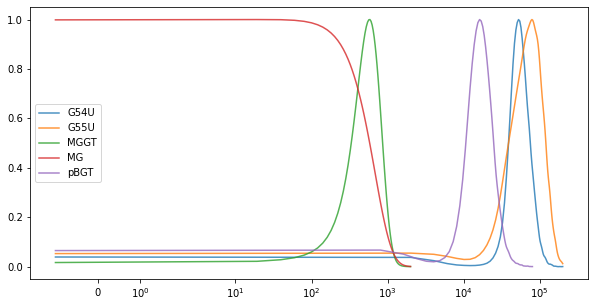

In [15]:
pltdf=df_all[(df_all["Area_M04"]<30)&(df_all["Aspect Ratio_M04"]<.8)&(df_all["Aspect Ratio_M04"]>.25)]
#pltdf=df_all.copy()

fig,ax=plt.subplots(figsize=(10,5))


this_gs=pltdf["GFP"]
max_g=this_gs.max()
xs=np.linspace(-1000,max_g,1000)
xmin=-1000
#maxs=[300000,120000,300000,2000,2000,80000]
maxs=[200000,200000,2000,2000,80000]
for i,strain in enumerate(strains):
    this_df=pltdf[pltdf["strain"]==strain]
    this_gs=this_df["GFP"]
    
    vc=this_gs.std()/this_gs.mean()
    print(strain," VC:",vc)
    max_g=maxs[i]
    xs=np.linspace(-1,max_g,100)
    this_gs=this_gs.where(this_gs>xmin,0)
    
    den=gaussian_kde(this_gs)
    #ys=den(xs)
    ys=den.evaluate(xs)
    ymax=ys.max()
    ys=ys/ymax
    ax.plot(xs,ys,label=strain,alpha=.8)
    
plt.legend()
plt.xscale("symlog")
plt.show()